# Extended NeRF

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import clear_output
import json
import time

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

CONFIG = {
    "seed": 42,
    "near": 2.0,
    "far": 6.0,
    "batch_size": 1024,
    "learning_rate": 5e-4,
    "num_epochs": 100,
    "num_coarse": 32,
    "num_fine": 64,
    "position_frequencies": 6,
    "direction_frequencies": 4,
    "hidden_width": 128,
    "retrain": False,  # Set to True to force retraining even if checkpoint exists
}
os.makedirs('weights', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)


Using device: cuda


## Dataset Loading

In [2]:
data = np.load('tiny_nerf_data.npz')
images = torch.from_numpy(data['images']).float()
poses = torch.from_numpy(data['poses']).float()
focal = float(data['focal'])
H, W = images.shape[1:3]

K = torch.tensor([
    [focal, 0, 0.5 * W],
    [0, focal, 0.5 * H],
    [0, 0, 1]
], dtype=torch.float32).to(device)

print(f"Dataset: Images shape={images.shape}, Poses shape={poses.shape}, Focal={focal}")

Dataset: Images shape=torch.Size([106, 100, 100, 3]), Poses shape=torch.Size([106, 4, 4]), Focal=138.88887889922103


## Train/Test Split

In [3]:
train_images, train_poses = images[:100], poses[:100]
test_images, test_poses = images[100:], poses[100:]

print(f"Train images: {train_images.shape}, Train poses: {train_poses.shape}")
print(f"Test images: {test_images.shape}, Test poses: {test_poses.shape}")

Train images: torch.Size([100, 100, 100, 3]), Train poses: torch.Size([100, 4, 4])
Test images: torch.Size([6, 100, 100, 3]), Test poses: torch.Size([6, 4, 4])


## Ray Generation (get_rays)

In [4]:
def get_rays(K, c2w, H, W):
    i, j = torch.meshgrid(
        torch.arange(W, dtype=torch.float32, device=c2w.device),
        torch.arange(H, dtype=torch.float32, device=c2w.device),
        indexing='xy'
    )
    dirs = torch.stack([
        (i - K[0, 2]) / K[0, 0],
        -(j - K[1, 2]) / K[1, 1],
        -torch.ones_like(i)
    ], dim=-1)
    rays_d = dirs @ c2w[:3, :3].T
    rays_o = c2w[:3, -1].expand(rays_d.shape)
    return rays_o, rays_d

## NeRFDataset and DataLoader

In [5]:
class NeRFDataset(torch.utils.data.Dataset):
    def __init__(self, images, poses, intrinsic):
        self.images, self.poses, self.intrinsic = images, poses, intrinsic
        self.H, self.W = images.shape[1], images.shape[2]
        self.all_rays_o, self.all_rays_d, self.all_rays_rgbs = [], [], []
        for i in range(len(images)):
            rays_o, rays_d = get_rays(self.intrinsic, self.poses[i].to(device), self.H, self.W)
            self.all_rays_o.append(rays_o.reshape(-1, 3).cpu())
            self.all_rays_d.append(rays_d.reshape(-1, 3).cpu())
            self.all_rays_rgbs.append(images[i].reshape(-1, 3))
        self.all_rays_o = torch.cat(self.all_rays_o, dim=0)
        self.all_rays_d = torch.cat(self.all_rays_d, dim=0)
        self.all_rays_rgbs = torch.cat(self.all_rays_rgbs, dim=0)

    def __len__(self):
        return len(self.all_rays_o)

    def __getitem__(self, idx):
        return (self.all_rays_o[idx], self.all_rays_d[idx], self.all_rays_rgbs[idx])

train_dataloader = torch.utils.data.DataLoader(
    NeRFDataset(train_images, train_poses, K),
    batch_size=CONFIG['batch_size'], shuffle=True
)

## Positional Encoding

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, L_embed=6):
        super().__init__()
        self.L_embed = L_embed
        self.register_buffer(
            'bands',
            (2.0 ** torch.arange(L_embed, dtype=torch.float32) * torch.pi).view(1, L_embed, 1)
        )

    def forward(self, x):
        x_scaled = x.unsqueeze(-2) * self.bands
        sin_cos = torch.cat([torch.sin(x_scaled), torch.cos(x_scaled)], dim=-2)
        sin_cos = sin_cos.flatten(start_dim=-2)
        return torch.cat([x, sin_cos], dim=-1)

## TASK 1: View-Dependent NeRF Model

In [7]:
class NeRF(nn.Module):
    """NeRF with view-direction conditioning.
    Density depends on position only; color depends on position features + view direction."""
    def __init__(self, filter_size=128, L_embed=6, L_dir=4):
        super().__init__()
        self.positional_encoding = PositionalEncoding(L_embed)
        self.direction_encoding = PositionalEncoding(L_dir)
        x_dim = 3 + 3 * 2 * L_embed  # 39 for L=6
        d_dim = 3 + 3 * 2 * L_dir    # 27 for L=4
        
        # Position trunk
        self.layer1 = nn.Linear(x_dim, filter_size)
        self.layer2 = nn.Linear(filter_size, filter_size)
        
        # Density (position only)
        self.sigma_layer = nn.Linear(filter_size, 1)
        # Feature vector
        self.feature_layer = nn.Linear(filter_size, filter_size)
        
        # Color head (features + direction)
        self.color_layer1 = nn.Linear(filter_size + d_dim, filter_size // 2)
        self.color_layer2 = nn.Linear(filter_size // 2, 3)

    def forward(self, x, view_dirs):
        # Encode position
        x_encoded = self.positional_encoding(x)
        
        # Position trunk
        h = F.relu(self.layer1(x_encoded))
        h = F.relu(self.layer2(h))
        
        # Density from position only
        sigma = F.relu(self.sigma_layer(h))
        
        # Feature vector
        features = self.feature_layer(h)
        
        # Normalize and encode direction
        view_dirs = F.normalize(view_dirs, dim=-1)
        d_encoded = self.direction_encoding(view_dirs)
        
        # Color conditioned on features + direction
        colour_input = torch.cat([features, d_encoded], dim=-1)
        colour_hidden = F.relu(self.color_layer1(colour_input))
        rgb = torch.sigmoid(self.color_layer2(colour_hidden))
        
        return torch.cat([sigma, rgb], dim=-1)

## Unit Tests for Task 1

In [8]:
print("=== Task 1 Unit Tests ===")
test_model = NeRF(filter_size=128, L_embed=6, L_dir=4).to(device)
N_test = 16
x_test = torch.randn(N_test, 3, device=device)
d_a = torch.randn(N_test, 3, device=device)
d_b = torch.randn(N_test, 3, device=device)

raw = test_model(x_test, d_a)
assert raw.shape == (N_test, 4), f"Shape mismatch: {raw.shape}"
assert torch.all(raw[:, 0] >= 0), "Density should be non-negative"
assert torch.all(raw[:, 1:] >= 0) and torch.all(raw[:, 1:] <= 1), "RGB should be in [0,1]"

raw_a = test_model(x_test, d_a)
raw_b = test_model(x_test, d_b)
assert torch.allclose(raw_a[:, 0], raw_b[:, 0], atol=1e-6), "Density must be view-independent!"
print("All Task 1 tests passed!")
print(f"Density unchanged: ✓")
print(f"RGB differs with direction: {not torch.allclose(raw_a[:, 1:], raw_b[:, 1:], atol=1e-6)}")
del test_model

=== Task 1 Unit Tests ===
All Task 1 tests passed!
Density unchanged: ✓
RGB differs with direction: True


## Volume Rendering

In [9]:
def volume_rendering(sigma, rgb, t_vals):
    deltas = t_vals[..., 1:] - t_vals[..., :-1]
    dist_shape = list(deltas.shape[:-1]) + [1]
    last_dist = torch.full(dist_shape, 1e10, device=sigma.device)
    deltas = torch.cat([deltas, last_dist], dim=-1)

    alpha = 1.0 - torch.exp(-sigma * deltas)
    shifted_transmittance = torch.cat([torch.ones_like(alpha[..., :1]), 1.0 - alpha + 1e-10], dim=-1)
    T = torch.cumprod(shifted_transmittance, dim=-1)[..., :-1]

    weights = alpha * T
    rgb_map = torch.sum(weights[..., None] * rgb, dim=-2)
    return rgb_map, weights

## sample_pdf for importance sampling

In [10]:
def sample_pdf(bins, weights, N_samples, rand=False):
    weights = weights + 1e-5
    pdf = weights / torch.sum(weights, dim=-1, keepdim=True)
    cdf = torch.cumsum(pdf, dim=-1)
    cdf = torch.cat([torch.zeros_like(cdf[..., :1]), cdf], dim=-1)
    
    if rand:
        u = torch.rand(list(cdf.shape[:-1]) + [N_samples], device=cdf.device)
    else:
        u = torch.linspace(0., 1., steps=N_samples, device=cdf.device)
        u = u.expand(list(cdf.shape[:-1]) + [N_samples])
    u = u.contiguous()
    
    inds = torch.searchsorted(cdf, u, right=True)
    below = torch.clamp(inds - 1, min=0)
    above = torch.clamp(inds, max=cdf.shape[-1] - 1)
    
    cdf_g0 = torch.gather(cdf, -1, below)
    cdf_g1 = torch.gather(cdf, -1, above)
    bins_g0 = torch.gather(bins, -1, below)
    bins_g1 = torch.gather(bins, -1, above)
    
    denom = cdf_g1 - cdf_g0
    denom = torch.where(denom < 1e-5, torch.ones_like(denom), denom)
    t = (u - cdf_g0) / denom
    samples = bins_g0 + t * (bins_g1 - bins_g0)
    return samples

## TASK 2: Hierarchical Rendering (render_rays)

In [11]:
def render_rays(coarse_network, fine_network, rays_o, rays_d, near, far, N_c, N_f, rand=False):
    original_shape = rays_o.shape[:-1]
    rays_o_flat = rays_o.reshape(-1, 3)
    rays_d_flat = rays_d.reshape(-1, 3)
    num_rays = rays_o_flat.shape[0]
    
    # --- COARSE PASS ---
    t_vals = torch.linspace(near, far, N_c, device=rays_o.device, dtype=rays_o.dtype)
    t_vals = t_vals.expand(num_rays, N_c)
    
    if rand:
        mids = 0.5 * (t_vals[..., 1:] + t_vals[..., :-1])
        upper = torch.cat([mids, t_vals[..., -1:]], dim=-1)
        lower = torch.cat([t_vals[..., :1], mids], dim=-1)
        t_rand = torch.rand_like(t_vals)
        t_vals = lower + (upper - lower) * t_rand
    
    points_c = rays_o_flat[:, None, :] + rays_d_flat[:, None, :] * t_vals[..., None]
    view_dirs = F.normalize(rays_d_flat, dim=-1)
    view_dirs_c = view_dirs[:, None, :].expand_as(points_c)
    
    raw_c = coarse_network(points_c.reshape(-1, 3), view_dirs_c.reshape(-1, 3))
    raw_c = raw_c.reshape(num_rays, N_c, 4)
    sigma_c = raw_c[..., 0]
    rgb_c = raw_c[..., 1:4]
    rgb_map_c, weights_c = volume_rendering(sigma_c, rgb_c, t_vals)
    
    # --- FINE PASS (Importance Sampling) ---
    t_mids = 0.5 * (t_vals[..., 1:] + t_vals[..., :-1])
    pdf_weights = weights_c[..., 1:-1]
    
    t_fine = sample_pdf(bins=t_mids, weights=pdf_weights.detach(), N_samples=N_f, rand=rand)
    
    t_all = torch.cat([t_vals, t_fine], dim=-1)
    t_all, _ = torch.sort(t_all, dim=-1)
    
    points_f = rays_o_flat[:, None, :] + rays_d_flat[:, None, :] * t_all[..., None]
    view_dirs_f = view_dirs[:, None, :].expand_as(points_f)
    
    raw_f = fine_network(points_f.reshape(-1, 3), view_dirs_f.reshape(-1, 3))
    raw_f = raw_f.reshape(num_rays, N_c + N_f, 4)
    sigma_f = raw_f[..., 0]
    rgb_f = raw_f[..., 1:4]
    rgb_map_f, weights_f = volume_rendering(sigma_f, rgb_f, t_all)
    
    rgb_map_c = rgb_map_c.reshape(*original_shape, 3)
    rgb_map_f = rgb_map_f.reshape(*original_shape, 3)
    return rgb_map_c, rgb_map_f

## Chunked image rendering

In [12]:
def render_image(coarse_model, fine_model, rays_o, rays_d, chunk_size=1024, **render_kwargs):
    H, W = rays_o.shape[0], rays_o.shape[1]
    rays_o_flat = rays_o.reshape(-1, 3)
    rays_d_flat = rays_d.reshape(-1, 3)
    rgb_c_chunks, rgb_f_chunks = [], []
    for i in range(0, rays_o_flat.shape[0], chunk_size):
        chunk_o = rays_o_flat[i:i+chunk_size]
        chunk_d = rays_d_flat[i:i+chunk_size]
        rgb_c, rgb_f = render_rays(coarse_model, fine_model, chunk_o, chunk_d, **render_kwargs)
        rgb_c_chunks.append(rgb_c)
        rgb_f_chunks.append(rgb_f)
    rgb_map_c = torch.cat(rgb_c_chunks, dim=0).reshape(H, W, 3)
    rgb_map_f = torch.cat(rgb_f_chunks, dim=0).reshape(H, W, 3)
    return rgb_map_c, rgb_map_f

## Task 2 Shape Tests

In [13]:
print("=== Task 2 Shape Tests ===")
test_coarse = NeRF(filter_size=128, L_embed=6, L_dir=4).to(device)
test_fine = NeRF(filter_size=128, L_embed=6, L_dir=4).to(device)

B = 32
test_rays_o = torch.randn(B, 3, device=device)
test_rays_d = torch.randn(B, 3, device=device)

rgb_c, rgb_f = render_rays(test_coarse, test_fine, test_rays_o, test_rays_d,
                           near=2.0, far=6.0, N_c=32, N_f=64, rand=True)
assert rgb_c.shape == (B, 3), f"Coarse shape: {rgb_c.shape}"
assert rgb_f.shape == (B, 3), f"Fine shape: {rgb_f.shape}"
assert torch.isfinite(rgb_c).all(), "Coarse has non-finite values"
assert torch.isfinite(rgb_f).all(), "Fine has non-finite values"
print(f"Coarse output shape: {rgb_c.shape} ✓")
print(f"Fine output shape: {rgb_f.shape} ✓")
print("All Task 2 tests passed!")
del test_coarse, test_fine

=== Task 2 Shape Tests ===
Coarse output shape: torch.Size([32, 3]) ✓
Fine output shape: torch.Size([32, 3]) ✓
All Task 2 tests passed!


## Training

Skips retraining if checkpoints `weights/extended_coarse_best.pth` and `weights/extended_fine_best.pth` already exist.
To retrain from scratch, set `CONFIG['retrain'] = True` or `RETRAIN = True` in the cell below.

In [14]:
model_coarse = NeRF(filter_size=CONFIG['hidden_width'], L_embed=CONFIG['position_frequencies'], L_dir=CONFIG['direction_frequencies']).to(device)
model_fine = NeRF(filter_size=CONFIG['hidden_width'], L_embed=CONFIG['position_frequencies'], L_dir=CONFIG['direction_frequencies']).to(device)
optimizer = optim.Adam(list(model_coarse.parameters()) + list(model_fine.parameters()), lr=CONFIG['learning_rate'])

N_c, N_f = CONFIG['num_coarse'], CONFIG['num_fine']
near, far = CONFIG['near'], CONFIG['far']
N_epochs = CONFIG['num_epochs']

train_psnrs = []
test_psnrs = []
train_losses = []
best_test_psnr = 0.0
start_time = time.time()

print(f"Coarse model parameters: {sum(p.numel() for p in model_coarse.parameters())}")
print(f"Fine model parameters: {sum(p.numel() for p in model_fine.parameters())}")
print(f"Total parameters: {sum(p.numel() for p in model_coarse.parameters()) + sum(p.numel() for p in model_fine.parameters())}")

# Set RETRAIN = True to force retraining even if weights exist
RETRAIN = CONFIG.get('retrain', False)
coarse_path = 'weights/extended_coarse_best.pth'
fine_path = 'weights/extended_fine_best.pth'

if os.path.exists(coarse_path) and os.path.exists(fine_path) and not RETRAIN:
    print(f"Found existing checkpoints at '{coarse_path}' and '{fine_path}'. Skipping training.")
    print("Set CONFIG['retrain'] = True or RETRAIN = True to force retraining.")
    try:
        checkpoint_c = torch.load(coarse_path, map_location=device, weights_only=False)
        checkpoint_f = torch.load(fine_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint_c = torch.load(coarse_path, map_location=device)
        checkpoint_f = torch.load(fine_path, map_location=device)
    model_coarse.load_state_dict(checkpoint_c['model_state_dict'])
    model_fine.load_state_dict(checkpoint_f['model_state_dict'])
    model_coarse.eval()
    model_fine.eval()
    train_psnrs = checkpoint_c.get('train_psnrs', [])
    test_psnrs = checkpoint_c.get('test_psnrs', [])
    train_losses = checkpoint_c.get('train_losses', [])
    total_time = checkpoint_c.get('total_training_time', 0.0)
    best_test_psnr = max(test_psnrs) if test_psnrs else 0.0
    print(f"Loaded coarse & fine models (epoch {checkpoint_c.get('epoch', 'N/A')}, best test PSNR: {best_test_psnr:.2f} dB, training time: {total_time:.1f}s).")
else:
    for epoch in range(N_epochs):
        model_coarse.train()
        model_fine.train()
        sse = 0.0
        num_values = 0
        epoch_loss = 0.0
        batch_count = 0
        
        for rays_o, rays_d, rays_rgb in train_dataloader:
            rays_o = rays_o.to(device, non_blocking=True)
            rays_d = rays_d.to(device, non_blocking=True)
            rays_rgb = rays_rgb.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            rgb_c, rgb_f = render_rays(model_coarse, model_fine, rays_o, rays_d, near=near, far=far, N_c=N_c, N_f=N_f, rand=True)
            
            loss_c = F.mse_loss(rgb_c, rays_rgb)
            loss_f = F.mse_loss(rgb_f, rays_rgb)
            loss = loss_c + loss_f
            
            loss.backward()
            optimizer.step()
            
            sse += F.mse_loss(rgb_f, rays_rgb, reduction='sum').item()
            num_values += rays_rgb.numel()
            epoch_loss += loss.item()
            batch_count += 1
        
        epoch_mse = sse / num_values
        epoch_psnr = -10.0 * np.log10(epoch_mse)
        train_psnrs.append(float(epoch_psnr))
        train_losses.append(float(epoch_loss / batch_count))
        
        # Test evaluation every 10 epochs or last epoch
        if (epoch + 1) % 10 == 0 or epoch == N_epochs - 1:
            model_coarse.eval()
            model_fine.eval()
            with torch.inference_mode():
                avg_test_psnr = 0.0
                for test_idx in range(len(test_images)):
                    testimg = test_images[test_idx].to(device)
                    testpose = test_poses[test_idx].to(device)
                    rays_o, rays_d = get_rays(K, testpose, H, W)
                    _, rgb = render_image(model_coarse, model_fine, rays_o, rays_d, near=near, far=far, N_c=N_c, N_f=N_f, rand=False)
                    test_mse = F.mse_loss(rgb, testimg).item()
                    psnr = -10.0 * np.log10(test_mse)
                    avg_test_psnr += psnr
                avg_test_psnr /= len(test_images)
                test_psnrs.append(float(avg_test_psnr))
                
                if avg_test_psnr > best_test_psnr:
                    best_test_psnr = avg_test_psnr
                    torch.save({
                        'model_state_dict': model_coarse.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'epoch': epoch,
                        'config': CONFIG,
                        'train_psnrs': [float(x) for x in train_psnrs],
                        'test_psnrs': [float(x) for x in test_psnrs],
                        'train_losses': [float(x) for x in train_losses],
                        'total_training_time': float(time.time() - start_time),
                    }, 'weights/extended_coarse_best.pth')
                    torch.save({
                        'model_state_dict': model_fine.state_dict(),
                        'epoch': epoch,
                        'config': CONFIG,
                    }, 'weights/extended_fine_best.pth')
                
                print(f"Epoch {epoch+1}/{N_epochs} | Train PSNR: {epoch_psnr:.2f} | Test PSNR: {avg_test_psnr:.2f} | Best: {best_test_psnr:.2f}")
            torch.cuda.empty_cache()
        else:
            print(f"Epoch {epoch+1}/{N_epochs} | Train PSNR: {epoch_psnr:.2f}")

    total_time = time.time() - start_time
    print(f"Training complete in {total_time:.1f}s")
    print(f"Best test PSNR: {best_test_psnr:.2f} dB")


Coarse model parameters: 48452
Fine model parameters: 48452
Total parameters: 96904
Epoch 1/100 | Train PSNR: 16.52
Epoch 2/100 | Train PSNR: 21.39
Epoch 3/100 | Train PSNR: 22.29
Epoch 4/100 | Train PSNR: 22.88
Epoch 5/100 | Train PSNR: 23.34
Epoch 6/100 | Train PSNR: 23.75
Epoch 7/100 | Train PSNR: 24.09
Epoch 8/100 | Train PSNR: 24.43
Epoch 9/100 | Train PSNR: 24.71
Epoch 10/100 | Train PSNR: 24.95 | Test PSNR: 25.47 | Best: 25.47
Epoch 11/100 | Train PSNR: 25.18
Epoch 12/100 | Train PSNR: 25.36
Epoch 13/100 | Train PSNR: 25.57
Epoch 14/100 | Train PSNR: 25.73
Epoch 15/100 | Train PSNR: 25.87
Epoch 16/100 | Train PSNR: 26.01
Epoch 17/100 | Train PSNR: 26.16
Epoch 18/100 | Train PSNR: 26.27
Epoch 19/100 | Train PSNR: 26.39
Epoch 20/100 | Train PSNR: 26.49 | Test PSNR: 26.96 | Best: 26.96
Epoch 21/100 | Train PSNR: 26.60
Epoch 22/100 | Train PSNR: 26.69
Epoch 23/100 | Train PSNR: 26.77
Epoch 24/100 | Train PSNR: 26.85
Epoch 25/100 | Train PSNR: 26.92
Epoch 26/100 | Train PSNR: 26.99
E

## Evaluation

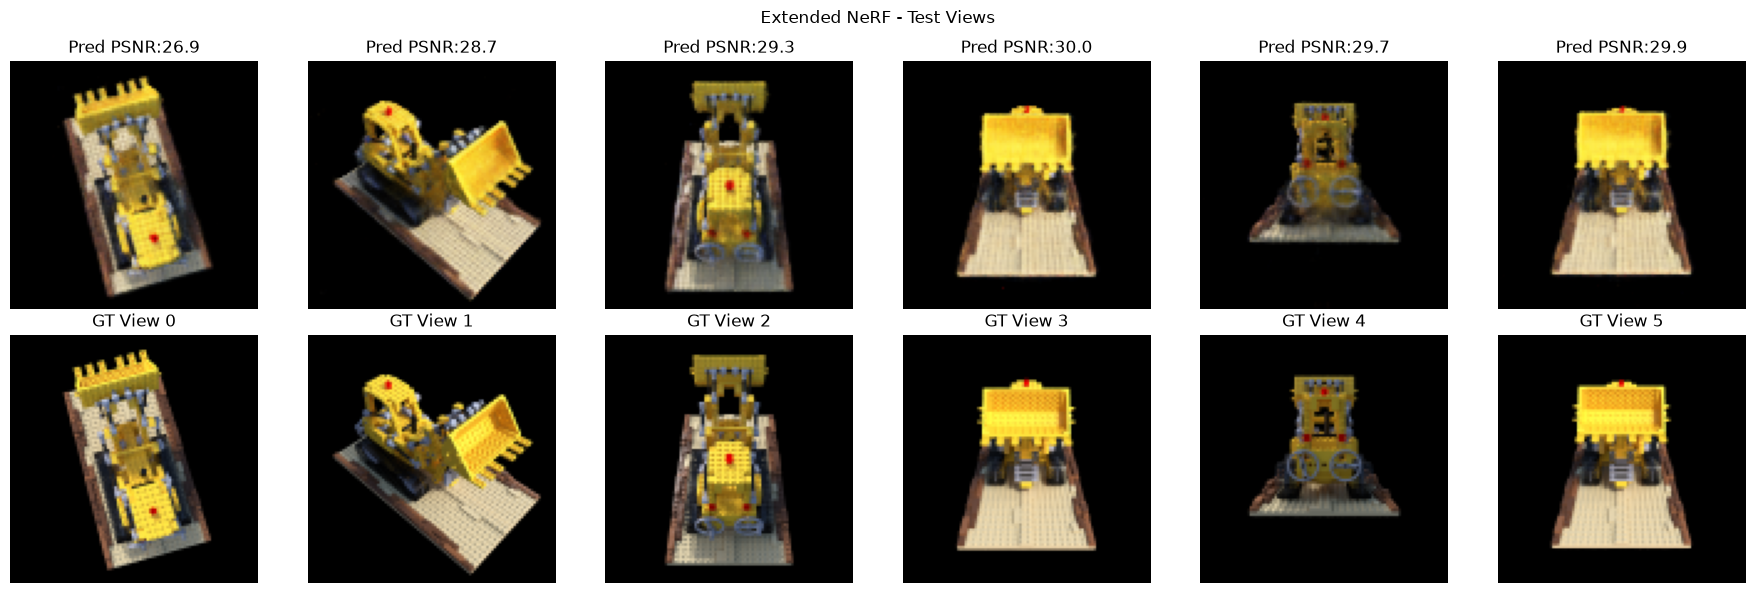

Extended Mean Test PSNR: 29.08 ± 1.07 dB
Metrics saved to results/extended_metrics.json


In [15]:
# Load best checkpoints
try:
    checkpoint_c = torch.load('weights/extended_coarse_best.pth', map_location=device, weights_only=False)
    checkpoint_f = torch.load('weights/extended_fine_best.pth', map_location=device, weights_only=False)
except TypeError:
    checkpoint_c = torch.load('weights/extended_coarse_best.pth', map_location=device)
    checkpoint_f = torch.load('weights/extended_fine_best.pth', map_location=device)
model_coarse.load_state_dict(checkpoint_c['model_state_dict'])
model_fine.load_state_dict(checkpoint_f['model_state_dict'])
model_coarse.eval()
model_fine.eval()

near, far = CONFIG['near'], CONFIG['far']
N_c, N_f = CONFIG['num_coarse'], CONFIG['num_fine']
train_psnrs = checkpoint_c.get('train_psnrs', train_psnrs if 'train_psnrs' in locals() else [])
test_psnrs = checkpoint_c.get('test_psnrs', test_psnrs if 'test_psnrs' in locals() else [])
train_losses = checkpoint_c.get('train_losses', train_losses if 'train_losses' in locals() else [10.0 ** (-p / 10.0) for p in train_psnrs])
total_time = checkpoint_c.get('total_training_time', total_time if 'total_time' in locals() else 0.0)

per_view_metrics = []
with torch.inference_mode():
    fig, axes = plt.subplots(2, len(test_images), figsize=(3*len(test_images), 6))
    for test_idx in range(len(test_images)):
        testimg = test_images[test_idx].to(device)
        testpose = test_poses[test_idx].to(device)
        rays_o, rays_d = get_rays(K, testpose, H, W)
        _, rgb = render_image(model_coarse, model_fine, rays_o, rays_d, near=near, far=far, N_c=N_c, N_f=N_f, rand=False)
        test_mse = F.mse_loss(rgb, testimg).item()
        psnr = -10.0 * np.log10(test_mse)
        per_view_metrics.append({'view': test_idx, 'mse': test_mse, 'psnr': psnr})
        
        axes[0, test_idx].imshow(rgb.cpu().numpy().clip(0, 1))
        axes[0, test_idx].set_title(f'Pred PSNR:{psnr:.1f}')
        axes[0, test_idx].axis('off')
        axes[1, test_idx].imshow(testimg.cpu().numpy())
        axes[1, test_idx].set_title(f'GT View {test_idx}')
        axes[1, test_idx].axis('off')
    plt.suptitle('Extended NeRF - Test Views')
    plt.tight_layout()
    plt.savefig('results/figures/extended_test_views.png', dpi=150, bbox_inches='tight')
    plt.show()

mean_psnr = np.mean([m['psnr'] for m in per_view_metrics])
std_psnr = np.std([m['psnr'] for m in per_view_metrics])
print(f"Extended Mean Test PSNR: {mean_psnr:.2f} ± {std_psnr:.2f} dB")

metrics = {
    'per_view': per_view_metrics,
    'mean_psnr': float(mean_psnr),
    'std_psnr': float(std_psnr),
    'min_psnr': float(np.min([m['psnr'] for m in per_view_metrics])),
    'max_psnr': float(np.max([m['psnr'] for m in per_view_metrics])),
    'train_psnrs': [float(x) for x in train_psnrs],
    'test_psnrs': [float(x) for x in test_psnrs],
    'train_losses': [float(x) for x in train_losses],
    'total_training_time': float(total_time),
    'num_parameters_coarse': sum(p.numel() for p in model_coarse.parameters()),
    'num_parameters_fine': sum(p.numel() for p in model_fine.parameters()),
    'config': CONFIG,
}
with open('results/extended_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("Metrics saved to results/extended_metrics.json")

## Novel View Rendering

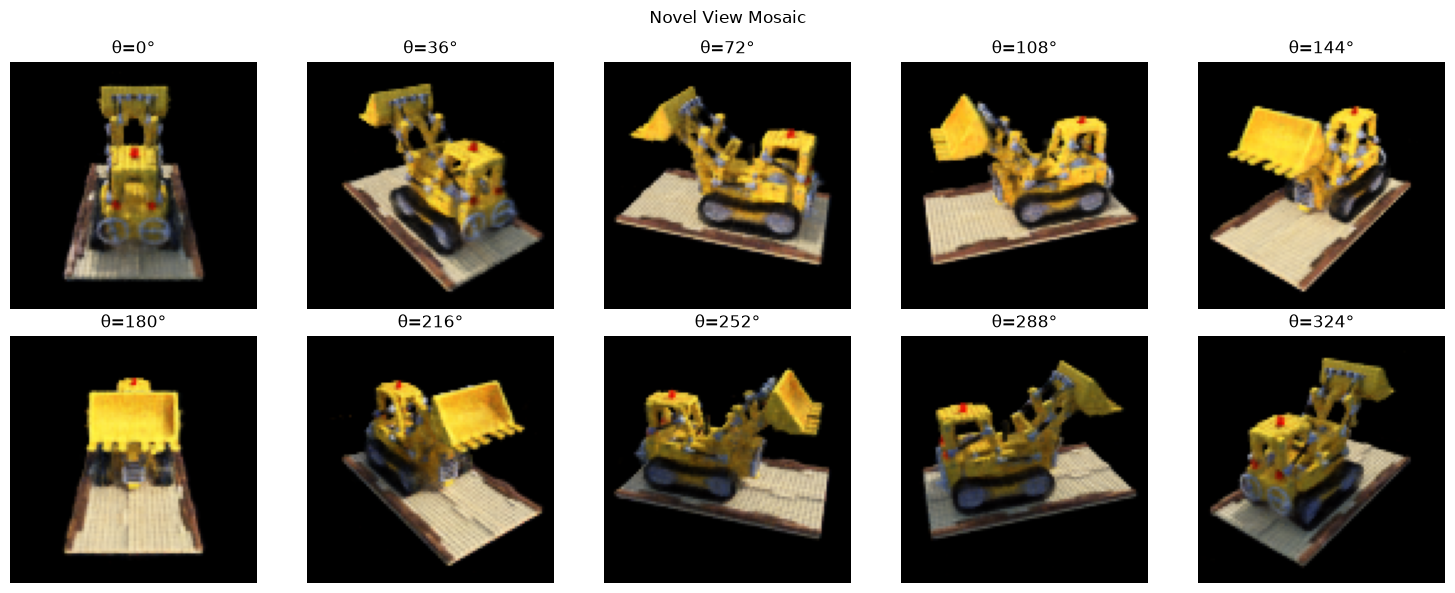

In [16]:
trans_t = lambda t: torch.tensor([[1,0,0,0],[0,1,0,0],[0,0,1,t],[0,0,0,1]], dtype=torch.float32)
rot_phi = lambda phi: torch.tensor([[1,0,0,0],[0,torch.cos(phi),-torch.sin(phi),0],[0,torch.sin(phi),torch.cos(phi),0],[0,0,0,1]], dtype=torch.float32)
rot_theta = lambda th: torch.tensor([[torch.cos(th),0,-torch.sin(th),0],[0,1,0,0],[torch.sin(th),0,torch.cos(th),0],[0,0,0,1]], dtype=torch.float32)

def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = rot_phi(torch.tensor(phi / 180. * np.pi)) @ c2w
    c2w = rot_theta(torch.tensor(theta / 180. * np.pi)) @ c2w
    c2w = torch.tensor([[-1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]], dtype=torch.float32) @ c2w
    return c2w.to(device)

# Generate a novel view mosaic
model_coarse.eval()
model_fine.eval()
near, far = CONFIG['near'], CONFIG['far']
N_c, N_f = CONFIG['num_coarse'], CONFIG['num_fine']

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
angles = np.linspace(0, 360, 10, endpoint=False)
with torch.inference_mode():
    for i, theta in enumerate(angles):
        c2w = pose_spherical(theta, -30.0, 4.0)
        rays_o, rays_d = get_rays(K, c2w[:3, :4], H, W)
        _, rgb = render_image(model_coarse, model_fine, rays_o, rays_d, near=near, far=far, N_c=N_c, N_f=N_f, rand=False)
        row, col = i // 5, i % 5
        axes[row, col].imshow(rgb.cpu().numpy().clip(0, 1))
        axes[row, col].set_title(f'θ={theta:.0f}°')
        axes[row, col].axis('off')
plt.suptitle('Novel View Mosaic')
plt.tight_layout()
plt.savefig('results/figures/novel_view_mosaic.png', dpi=150, bbox_inches='tight')
plt.show()

## Training History Plot

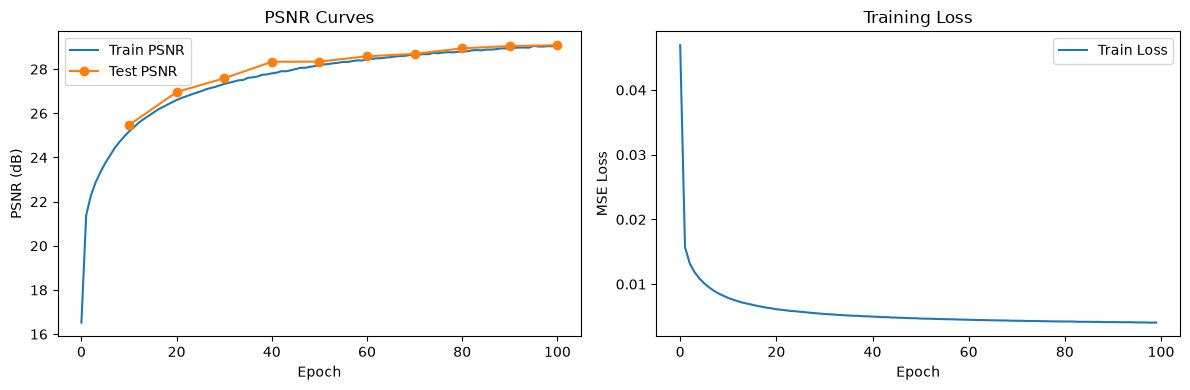

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
if 'train_psnrs' in locals() and len(train_psnrs) > 0:
    ax1.plot(train_psnrs, label='Train PSNR')
    if 'test_psnrs' in locals() and len(test_psnrs) > 0:
        test_epochs = np.linspace(10, CONFIG['num_epochs'], len(test_psnrs))
        ax1.plot(test_epochs, test_psnrs, label='Test PSNR', marker='o')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('PSNR (dB)'); ax1.legend(); ax1.set_title('PSNR Curves')
if 'train_losses' in locals() and len(train_losses) > 0:
    ax2.plot(train_losses, label='Train Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE Loss'); ax2.legend(); ax2.set_title('Training Loss')
plt.tight_layout()
plt.savefig('results/figures/extended_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()